# Targeted boosted-tree features

Notebook 4 selected a 15-leaf boosted tree with L2 regularization of 0.3 and raw probabilities. Its largest remaining errors were close to the deadline, above 30% of capacity, in Winter, at Scarborough, and in the middle probability range. This notebook tests focused feature groups against the unchanged Notebook 4 model.

In [1]:
from __future__ import annotations

import gc
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score
from sklearn.pipeline import Pipeline

cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    (path for path in (cwd, *cwd.parents) if (path / 'README.md').exists() and (path / 'model').exists()),
    cwd,
)
CACHE_ROOT = PROJECT_ROOT / 'artifacts' / 'feature-search-cache'
ROWS_PER_SESSION = 300_000
CACHE_VERSION = 4
TRAIN_ROWS_PER_FOLD = 2_000_000
SESSION_ORDER = ['20229', '20235', '20239', '20245', '20249', '20255', '20259', '20265']
VALIDATION_SESSIONS = ['20239', '20249', '20259', '20265']
RANDOM_STATE = 42

paths = {session: CACHE_ROOT / f'{session}-{ROWS_PER_SESSION}-v{CACHE_VERSION}.pkl' for session in SESSION_ORDER}
missing = [str(path) for path in paths.values() if not path.exists()]
if missing:
    raise FileNotFoundError('Run Notebook 1 to build the canonical cache. Missing: ' + ', '.join(missing))
session_samples = {session: pd.read_pickle(path) for session, path in paths.items()}
print(f'Loaded {sum(map(len, session_samples.values())):,} cached rows')

Loaded 2,379,974 cached rows


## 1. Targeted feature groups

Boosted trees already learn nonlinear thresholds, so each group must beat the unmodified baseline rather than receiving credit merely for being more elaborate. The final context group adds numeric campus and term indicators because Notebook 4's numeric-only winner did not receive those inputs.

In [2]:
BASE_NUMERIC = [
    'position_to_capacity', 'waitlist_to_capacity', 'days_to_deadline',
    'movement_3d', 'movement_7d', 'position', 'waitlist', 'capacity',
    'capacity_changed_7d', 'position_to_waitlist', 'days_squared',
    'log_waitlist', 'movement_velocity_7d',
]

def add_targeted_features(frame):
    frame = frame.copy()
    days = frame['days_to_deadline'].clip(lower=0)
    near_7 = days.le(7).astype('float32')
    winter = frame['term'].eq('winter').astype('float32')
    scarborough = frame['campus'].eq('SCAR').astype('float32')
    frame['near_deadline_7d'] = near_7
    frame['days_under_7'] = (7 - days).clip(lower=0).astype('float32')
    frame['days_under_14'] = (14 - days).clip(lower=0).astype('float32')
    frame['days_over_60'] = (days - 60).clip(lower=0).astype('float32')
    frame['position_ratio_near_7d'] = (frame['position_to_capacity'] * near_7).astype('float32')
    frame['waitlist_ratio_near_7d'] = (frame['waitlist_to_capacity'] * near_7).astype('float32')
    frame['rank_over_30pct'] = frame['position_to_capacity'].gt(.30).astype('float32')
    frame['campus_erin'] = frame['campus'].eq('ERIN').astype('float32')
    frame['campus_scar'] = scarborough
    frame['term_winter'] = winter
    frame['term_full_year'] = frame['term'].eq('full_year').astype('float32')
    frame['winter_near_7d'] = (winter * near_7).astype('float32')
    frame['scar_near_7d'] = (scarborough * near_7).astype('float32')
    return frame

session_samples = {session: add_targeted_features(frame) for session, frame in session_samples.items()}
DEADLINE = BASE_NUMERIC + ['near_deadline_7d', 'days_under_7', 'days_under_14', 'days_over_60']
RANK_DEADLINE = DEADLINE + [
    'position_ratio_near_7d', 'waitlist_ratio_near_7d', 'rank_over_30pct',
]
CONTEXT = RANK_DEADLINE + [
    'campus_erin', 'campus_scar', 'term_winter', 'term_full_year',
    'winter_near_7d', 'scar_near_7d',
]
FEATURE_SETS = {
    'baseline': BASE_NUMERIC,
    'deadline': DEADLINE,
    'rank_deadline': RANK_DEADLINE,
    'rank_deadline_context': CONTEXT,
}

def make_model(numeric):
    return Pipeline([
        ('features', ColumnTransformer([
            ('numeric', SimpleImputer(strategy='median'), numeric),
        ])),
        ('model', HistGradientBoostingClassifier(
            learning_rate=0.05, max_iter=200, max_leaf_nodes=15,
            l2_regularization=3.0, random_state=RANDOM_STATE,
        )),
    ])

def weighted_rate(values, weights):
    return float(np.average(values, weights=weights))

def weighted_ece(y, probability, weight, bins=10):
    groups = np.clip(np.digitize(probability, np.linspace(0, 1, bins + 1)) - 1, 0, bins - 1)
    error = 0.0
    for group in range(bins):
        mask = groups == group
        if mask.any():
            error += weight[mask].sum() / weight.sum() * abs(
                weighted_rate(y[mask], weight[mask]) - weighted_rate(probability[mask], weight[mask])
            )
    return float(error)

def signed_subgroup_gap(frame, probability, mask):
    if not mask.any():
        return np.nan
    weight = frame.loc[mask, 'model_weight'].to_numpy()
    return weighted_rate(probability[mask], weight) - weighted_rate(frame.loc[mask, 'cleared'], weight)

def max_probability_gap(frame, probability):
    bands = pd.cut(probability, np.linspace(0, 1, 11), include_lowest=True)
    gaps = []
    for band in bands.categories:
        mask = np.asarray(bands == band)
        if mask.sum() >= 100:
            gaps.append(abs(signed_subgroup_gap(frame, probability, mask)))
    return max(gaps) if gaps else np.nan

print({name: len(columns) for name, columns in FEATURE_SETS.items()})

{'baseline': 13, 'deadline': 17, 'rank_deadline': 20, 'rank_deadline_context': 26}


## 2. Chronological feature ablation

Every candidate uses the same rows, boosted-tree settings, and chronological folds. Subgroup gaps are signed: positive values mean overprediction and negative values mean underprediction.

In [3]:
RESULTS_PATH = CACHE_ROOT / 'boosted-targeted-features-v2.pkl'
results = pd.read_pickle(RESULTS_PATH).to_dict('records') if RESULTS_PATH.exists() else []
completed = {(row['validation_session'], row['candidate']) for row in results}

for fold_number, valid_session in enumerate(VALIDATION_SESSIONS, start=1):
    valid_index = SESSION_ORDER.index(valid_session)
    train = pd.concat([session_samples[s] for s in SESSION_ORDER[:valid_index]], ignore_index=True)
    model_train = train.sample(n=min(TRAIN_ROWS_PER_FOLD, len(train)), random_state=RANDOM_STATE)
    valid = session_samples[valid_session]
    y, weight = valid['cleared'].to_numpy(), valid['model_weight'].to_numpy()
    reference_probability = weighted_rate(train['cleared'], train['model_weight'])
    reference_brier = brier_score_loss(y, np.full(len(y), reference_probability), sample_weight=weight)
    print(f'Fold {valid_session}: {len(model_train):,} training rows; {len(valid):,} validation rows', flush=True)

    for candidate_number, (name, numeric) in enumerate(FEATURE_SETS.items(), start=1):
        key = (valid_session, name)
        if key in completed:
            print(f'[{fold_number}/4, {candidate_number}/{len(FEATURE_SETS)}] {name}: cached', flush=True)
            continue
        started = time.perf_counter()
        print(f'[{fold_number}/4, {candidate_number}/{len(FEATURE_SETS)}] {name}: fitting', flush=True)
        model = make_model(numeric)
        model.fit(model_train[numeric], model_train['cleared'], model__sample_weight=model_train['model_weight'])
        probability = np.clip(model.predict_proba(valid[numeric])[:, 1], 1e-6, 1 - 1e-6)
        near = valid['days_to_deadline'].le(7).to_numpy()
        winter = valid['term'].eq('winter').to_numpy()
        scarborough = valid['campus'].eq('SCAR').to_numpy()
        large_queue = valid['position_to_capacity'].gt(.30).to_numpy()
        brier = brier_score_loss(y, probability, sample_weight=weight)
        results.append({
            'validation_session': valid_session, 'candidate': name,
            'brier': brier, 'brier_skill': 1 - brier / reference_brier,
            'log_loss': log_loss(y, probability, sample_weight=weight, labels=[0, 1]),
            'ece_10': weighted_ece(y, probability, weight),
            'roc_auc': roc_auc_score(y, probability, sample_weight=weight),
            'near_7d_gap': signed_subgroup_gap(valid, probability, near),
            'winter_gap': signed_subgroup_gap(valid, probability, winter),
            'scarborough_gap': signed_subgroup_gap(valid, probability, scarborough),
            'large_queue_gap': signed_subgroup_gap(valid, probability, large_queue),
            'max_probability_gap': max_probability_gap(valid, probability),
            'seconds': time.perf_counter() - started,
        })
        pd.DataFrame(results).to_pickle(RESULTS_PATH)
        completed.add(key)
        print(f'  complete in {results[-1]["seconds"] / 60:.1f} min', flush=True)
        del model, probability
        gc.collect()
    del train, model_train
    gc.collect()

scores = pd.DataFrame(results).sort_values(['validation_session', 'brier']).reset_index(drop=True)
display(scores)

Fold 20239: 579,974 training rows; 300,000 validation rows


[1/4, 1/4] baseline: fitting


  complete in 0.0 min


[1/4, 2/4] deadline: fitting


  complete in 0.0 min


...

[4/4, 3/4] rank_deadline: fitting


  complete in 0.2 min


[4/4, 4/4] rank_deadline_context: fitting


  complete in 0.2 min


,validation_session,candidate,brier,brier_skill,log_loss,ece_10,roc_auc,near_7d_gap,winter_gap,scarborough_gap,large_queue_gap,max_probability_gap,seconds
0,20239,rank_deadline_context,0.049038,0.499850,0.161419,0.016098,0.955333,0.032438,0.015431,-0.003401,0.014141,0.092326,3.748482
1,20239,deadline,0.049448,0.495666,0.162667,0.016000,0.954567,0.036627,0.016454,0.005009,0.016085,0.102601,2.633462
2,20239,rank_deadline,0.049537,0.494753,0.163054,0.016279,0.954559,0.038905,0.016843,0.005005,0.016152,0.112702,2.982420
3,20239,baseline,0.049863,0.491429,0.164081,0.016074,0.954004,0.044539,0.016078,0.005858,0.017298,0.104877,2.404179
4,20249,rank_deadline_context,0.049427,0.548072,0.161766,0.016445,0.960125,0.042680,0.020820,0.002409,0.048937,0.098781,7.364223
5,20249,baseline,0.050982,0.533857,0.166407,0.019305,0.958046,0.064298,0.024891,0.008193,0.054876,0.102718,5.351077
6,20249,deadline,0.050996,0.533724,0.166400,0.017956,0.957805,0.049621,0.024467,0.005445,0.055423,0.095864,5.265200
7,20249,rank_deadline,0.051100,0.532776,0.166641,0.017491,0.957672,0.042919,0.024108,0.005367,0.054594,0.091287,6.284645
8,20259,rank_deadline_context,0.043507,0.538192,0.144345,0.008275,0.961100,0.018658,0.004386,0.024507,0.014730,0.048997,11.581474
9,20259,deadline,0.044752,0.524982,0.148702,0.008720,0.958133,0.019351,0.011182,0.026573,0.021376,0.051544,8.064582


## 3. Comparison and retention rule

A feature group should not be retained merely because it repairs one visible slice. Compare average and worst-fold probability error, calibration, discrimination, and the newest-fold signed gaps against `baseline`.

,mean_brier,worst_brier,min_skill,mean_log_loss,mean_ece,mean_auc,total_minutes,recent_brier,recent_ece_10,recent_near_7d_gap,recent_winter_gap,recent_scarborough_gap,recent_large_queue_gap,recent_max_probability_gap
candidate,,,,,,,,,,,,,,
rank_deadline_context,0.048816,0.053294,0.412052,0.164749,0.014991,0.948739,0.603107,0.053294,0.019145,0.130994,0.044350,0.030271,-0.016824,0.058291
deadline,0.050171,0.055488,0.387838,0.169841,0.015745,0.944643,0.422208,0.055488,0.020303,0.136431,0.048351,0.033888,-0.038393,0.061582
rank_deadline,0.050220,0.055444,0.388330,0.170053,0.015670,0.944574,0.482920,0.055444,0.020090,0.135226,0.048172,0.034183,-0.038229,0.064673
baseline,0.050340,0.055572,0.386911,0.170304,0.016323,0.944435,0.406769,0.055572,0.020426,0.140128,0.048231,0.034184,-0.039712,0.059043


candidate,baseline,deadline,rank_deadline,rank_deadline_context
validation_session,,,,
20239,0.049863,0.049448,0.049537,0.049038
20249,0.050982,0.050996,0.051100,0.049427
20259,0.044941,0.044752,0.044799,0.043507
20265,0.055572,0.055488,0.055444,0.053294


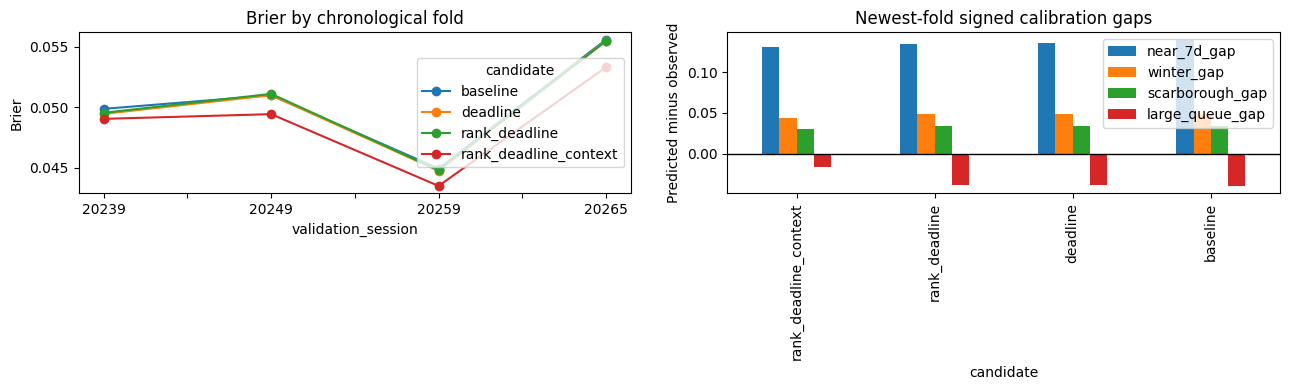

In [4]:
summary = scores.groupby('candidate').agg(
    mean_brier=('brier', 'mean'), worst_brier=('brier', 'max'),
    min_skill=('brier_skill', 'min'), mean_log_loss=('log_loss', 'mean'),
    mean_ece=('ece_10', 'mean'), mean_auc=('roc_auc', 'mean'),
    total_minutes=('seconds', lambda values: values.sum() / 60),
).sort_values(['mean_brier', 'mean_ece'])
recent = scores[scores['validation_session'] == VALIDATION_SESSIONS[-1]].set_index('candidate')
comparison = summary.join(recent[[
    'brier', 'ece_10', 'near_7d_gap', 'winter_gap', 'scarborough_gap',
    'large_queue_gap', 'max_probability_gap',
]].add_prefix('recent_'))
display(comparison)
display(scores.pivot(index='validation_session', columns='candidate', values='brier'))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
scores.pivot(index='validation_session', columns='candidate', values='brier').plot(marker='o', ax=axes[0])
recent[['near_7d_gap', 'winter_gap', 'scarborough_gap', 'large_queue_gap']].plot.bar(ax=axes[1])
axes[0].set(title='Brier by chronological fold', ylabel='Brier')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set(title='Newest-fold signed calibration gaps', ylabel='Predicted minus observed')
plt.tight_layout()
plt.show()

## 4. Findings and decision

All four variants used the same tuned boosted-tree settings, deterministic training rows, and chronological holdouts.

### Overall results

- `rank_deadline_context` had the best mean Brier at **0.04882**, the best worst-fold Brier at **0.05329**, and the best mean ROC AUC at **0.94874**.
- It reduced mean Brier by **3.0%** relative to the unchanged `baseline` and won all four chronological folds.
- On the newest `20265` fold, Brier fell from **0.05557** to **0.05329**.
- Deadline and rank features without context did not improve the four-fold average. The trees already learned nearly all useful nonlinear structure from the original continuous inputs.

### Tradeoffs

- Context reduced the newest Scarborough overprediction from **3.4** to **3.0 percentage points** and the Winter overprediction from **4.8** to **4.4 points**.
- The newest seven-day gap remained large at **13.1 points**, below the baseline's **14.0 points**.
- Mean ECE improved from **0.01632** to **0.01499**.
- The newest maximum probability-bin gap improved slightly from **5.9** to **5.8 points**, but the large near-deadline gap still requires seasonal validation.

### Decision

Carry both `baseline` and `rank_deadline_context` into Notebook 6. Compare them separately within Fall/Winter and Summer chronological folds. Seasonal evaluation should determine whether the context gain is stable within either calendar or whether the simpler baseline remains safer.